# ¿A quién le creemos más: a Marte o a un planeta a 124 años luz?

En 2025 hubo dos anuncios de posible vida fuera de la Tierra. En abril, gases raros en el exoplaneta **K2-18 b**. En septiembre, una roca marciana con manchas curiosas: **Cheyava Falls**. En vez de adivinar a quién le hizo más ruido a la comunidad, alguien hizo lo obvio: preguntarle directo a los astrobiólogos.

Votaron **920** en total. Y la sorpresa no es a quién le creyeron más — es cuánto siguieron dudando.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Vickers et al. (2026), *Nature Astronomy*
**DOI:** [10.1038/s41550-026-02876-9](https://doi.org/10.1038/s41550-026-02876-9)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-05-astrobiologos-vida-extraterrestre/notebook.ipynb)

*Video: [Ver en YouTube](https://youtube.com/shorts/zoMmSTf8wK4)*

## Qué votaron, exactamente

No votaron "¿hay vida sí o no?". Votaron **qué tan de acuerdo** estaban con que cada anuncio fuera evidencia real de vida, en una escala de cinco pasos: desde *totalmente de acuerdo* hasta *totalmente en desacuerdo*. A cada paso le corresponde un peso de confianza (lo que en el paper llaman *credence*): 0,95 para el sí rotundo, 0,05 para el no rotundo.

Fueron dos encuestas distintas, en momentos distintos: K2-18 b en abril–mayo de 2025 (496 votos), Cheyava Falls en septiembre–octubre (424 votos). Misma comunidad, misma plataforma, dos rocas — bueno, una roca y un planeta — bajo el mismo microscopio de opinión.

Una aclaración que vale oro: esto mide **cuánto convenció cada anuncio a los expertos**, no cuál evidencia es "más real". Son cosas distintas, y el paper es cuidadoso con eso. Nosotros también.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_K2 = '#2563EB'        # K2-18 b (exoplaneta) — azul CaM
COLOR_MARS = '#DC2626'      # Cheyava Falls / Marte — rojo
COLOR_NEUTRAL = '#BBBBBB'   # indecisos / contexto
FUENTE = 'Fuente: Vickers et al. (2026), Nature Astronomy | Datos: Supplementary Data 1'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Descargar datos si no están locales (Colab, Binder) ---
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
archivos = {
    'datos/votos_k2_18b.csv': f'{BASE}/papers/2026-06-05-astrobiologos-vida-extraterrestre/datos/votos_k2_18b.csv',
    'datos/votos_mars.csv': f'{BASE}/papers/2026-06-05-astrobiologos-vida-extraterrestre/datos/votos_mars.csv',
    'datos/distribucion_respuestas.csv': f'{BASE}/papers/2026-06-05-astrobiologos-vida-extraterrestre/datos/distribucion_respuestas.csv',
}
for local, url in archivos.items():
    if not os.path.exists(local):
        urllib.request.urlretrieve(url, local)

# --- Cargar estilo CaM ---
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# --- Cargar votos ---
k2 = pd.read_csv('datos/votos_k2_18b.csv')
mars = pd.read_csv('datos/votos_mars.csv')
dist = pd.read_csv('datos/distribucion_respuestas.csv')

# Orden de las categorías (de más a menos convencido)
ORDEN = ['Strongly agree', 'Agree', 'Neutral', 'Disagree', 'Strongly disagree']
ETIQUETAS_ES = ['Totalmente\nde acuerdo', 'De acuerdo', 'Neutral',
                'En desacuerdo', 'Totalmente en\ndesacuerdo']

print(f"K2-18 b      : {len(k2)} votos  (abril-mayo 2025)")
print(f"Cheyava Falls: {len(mars)} votos  (sept-octubre 2025)")
print(f"Total        : {len(k2) + len(mars)} astrobiólogos\n")
print(f"Confianza media — K2-18 b: {k2.credence.mean():.1%}  |  Marte: {mars.credence.mean():.1%}")
print(f"Confianza mediana — K2-18 b: {k2.credence.median():.2f}  |  Marte: {mars.credence.median():.2f}")


K2-18 b      : 496 votos  (abril-mayo 2025)
Cheyava Falls: 424 votos  (sept-octubre 2025)
Total        : 920 astrobiólogos

Confianza media — K2-18 b: 28.4%  |  Marte: 40.8%
Confianza mediana — K2-18 b: 0.25  |  Marte: 0.50


## Aquí está.

Ponemos las dos votaciones lado a lado, categoría por categoría.

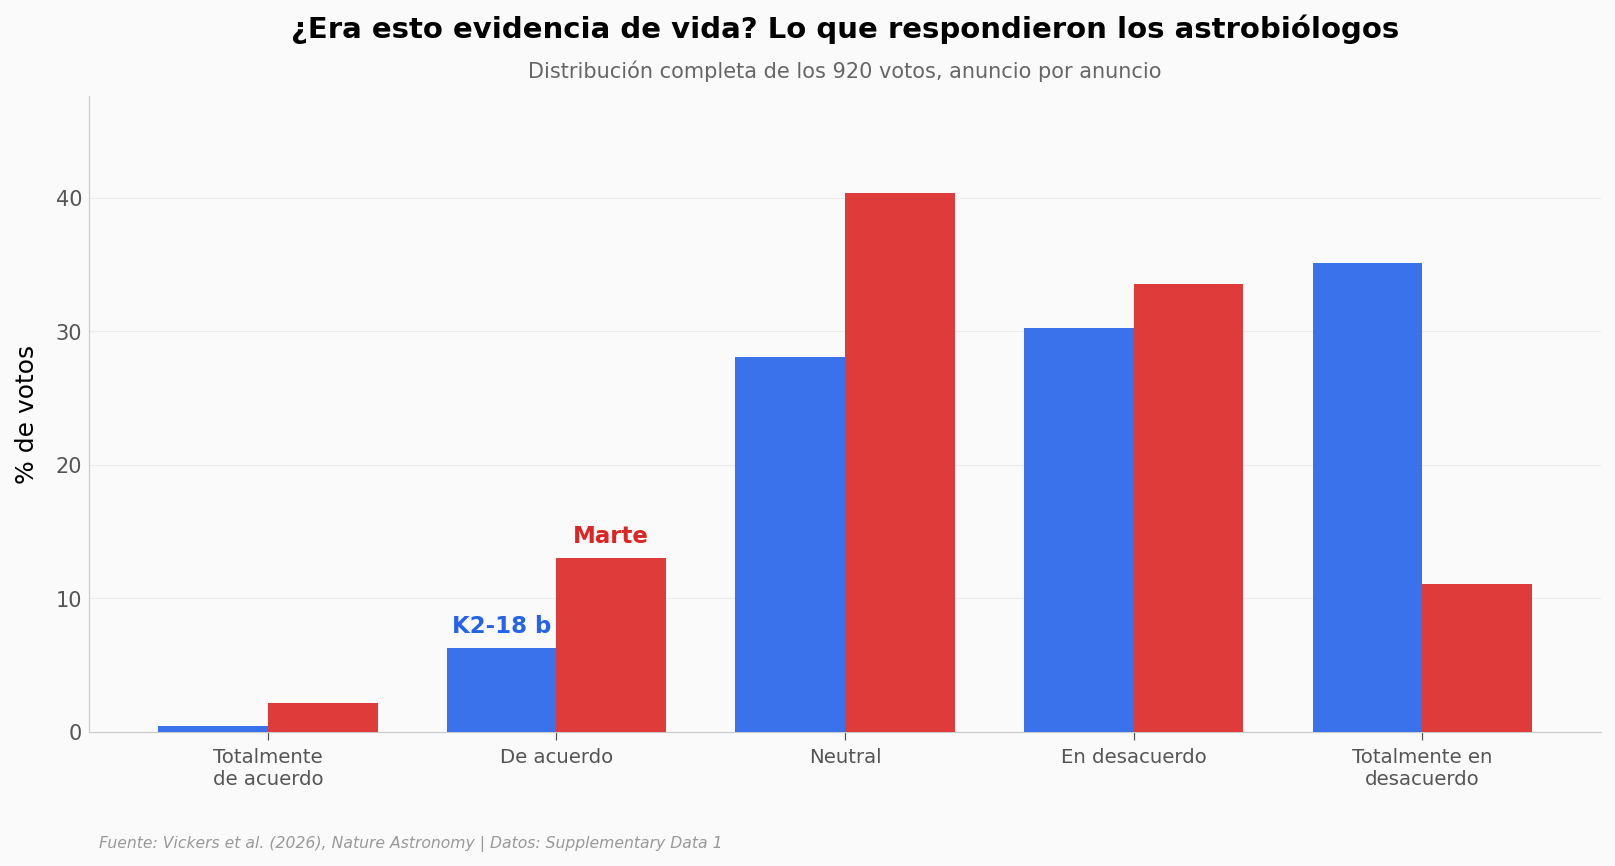

In [2]:
# Distribución de votos por categoría, en porcentaje, para cada anuncio
pct_k2 = [(k2.response_label == c).mean() * 100 for c in ORDEN]
pct_mars = [(mars.response_label == c).mean() * 100 for c in ORDEN]

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(ORDEN))
w = 0.38

ax.bar(x - w/2, pct_k2, w, color=COLOR_K2, alpha=0.9, label='K2-18 b', zorder=3)
ax.bar(x + w/2, pct_mars, w, color=COLOR_MARS, alpha=0.9, label='Cheyava Falls (Marte)', zorder=3)

# Etiquetas inline de cada serie (reemplazan la legend box)
ax.text(x[1] - w/2, pct_k2[1] + 1.2, 'K2-18 b', color=COLOR_K2,
        fontsize=11, fontweight='bold', ha='center')
ax.text(x[1] + w/2, pct_mars[1] + 1.2, 'Marte', color=COLOR_MARS,
        fontsize=11, fontweight='bold', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(ETIQUETAS_ES, fontsize=9.5)
ax.set_ylabel('% de votos')
ax.set_ylim(0, max(max(pct_k2), max(pct_mars)) * 1.18)
ax.set_title('¿Era esto evidencia de vida? Lo que respondieron los astrobiólogos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución completa de los 920 votos, anuncio por anuncio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_votos.png', dpi=200, bbox_inches='tight')
plt.show()


Lo que salta a la vista: el bloque de "totalmente en desacuerdo" se desploma cuando se pasa de K2-18 b a Marte — de 35% a 11%. Y los indecisos (*Neutral*) crecen hasta volverse la respuesta más votada en el caso marciano: cuatro de cada diez prefirieron no mojarse.

El "totalmente de acuerdo" casi no existe en ninguno de los dos. Apenas 9 personas en el caso más optimista. Nadie estaba listo para firmar que encontramos vida — pero Marte movió la aguja hacia el centro.

## El promedio, voto por voto

La distribución cuenta la forma; el promedio cuenta la distancia. Convertimos cada voto a su peso de confianza (0 a 1) y miramos dónde cae la nube de cada anuncio.

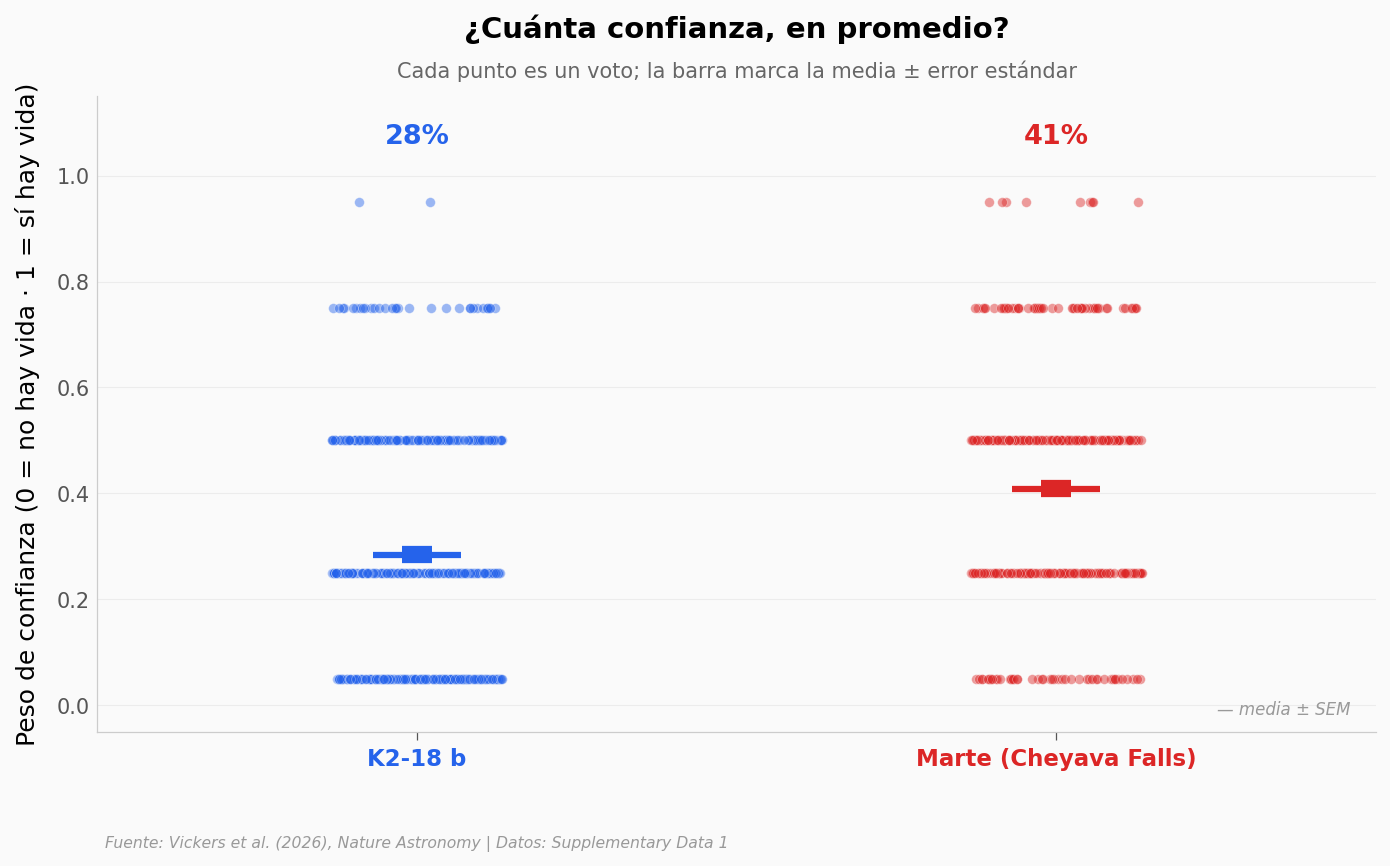

Diferencia: +12.4 puntos porcentuales (Marte mayor)
Mann-Whitney U = 137508,  p = 3.8e-17
Cohen's d = 0.57  (efecto medio)


In [3]:
np.random.seed(42)  # jitter reproducible
fig, ax = plt.subplots(figsize=(11, 5.5))

grupos = [('K2-18 b', k2.credence.values, COLOR_K2),
          ('Marte (Cheyava Falls)', mars.credence.values, COLOR_MARS)]
posiciones = [0, 1.2]

for pos, (nombre, vals, color) in zip(posiciones, grupos):
    n = len(vals)
    x_strip = np.linspace(pos - 0.16, pos + 0.16, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=22, alpha=0.45,
               edgecolors='white', linewidths=0.3, zorder=4)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color,
                markersize=42, markeredgewidth=3,
                capsize=7, capthick=1.5, zorder=6)
    ax.text(pos, 1.06, f'{media:.0%}', color=color, fontsize=13,
            fontweight='bold', ha='center')

# Prueba estadística (variable ordinal, dos grupos independientes → Mann-Whitney)
U, p = stats.mannwhitneyu(mars.credence, k2.credence, alternative='two-sided')
na, nb = len(mars), len(k2)
sp = np.sqrt(((na-1)*mars.credence.std(ddof=1)**2 + (nb-1)*k2.credence.std(ddof=1)**2) / (na+nb-2))
d = (mars.credence.mean() - k2.credence.mean()) / sp

ax.set_xticks(posiciones)
ax.set_xticklabels(['K2-18 b', 'Marte (Cheyava Falls)'], fontsize=11, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_K2)
ax.get_xticklabels()[1].set_color(COLOR_MARS)
ax.set_ylabel('Peso de confianza (0 = no hay vida · 1 = sí hay vida)')
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(-0.6, 1.8)
ax.set_title('¿Cuánta confianza, en promedio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un voto; la barra marca la media ± error estándar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '— media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/confianza_media.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Diferencia: +{(mars.credence.mean()-k2.credence.mean())*100:.1f} puntos porcentuales (Marte mayor)")
print(f"Mann-Whitney U = {U:.0f},  p = {p:.1e}")
print(f"Cohen's d = {d:.2f}  (efecto medio)")


## Pero ojo con el titular fácil

"Marte ganó" es verdad, pero a medias. Que un anuncio convenza *más* no significa que convenza *a la mayoría*. Para verlo limpio, sacamos a los indecisos y nos quedamos solo con quienes tomaron postura.

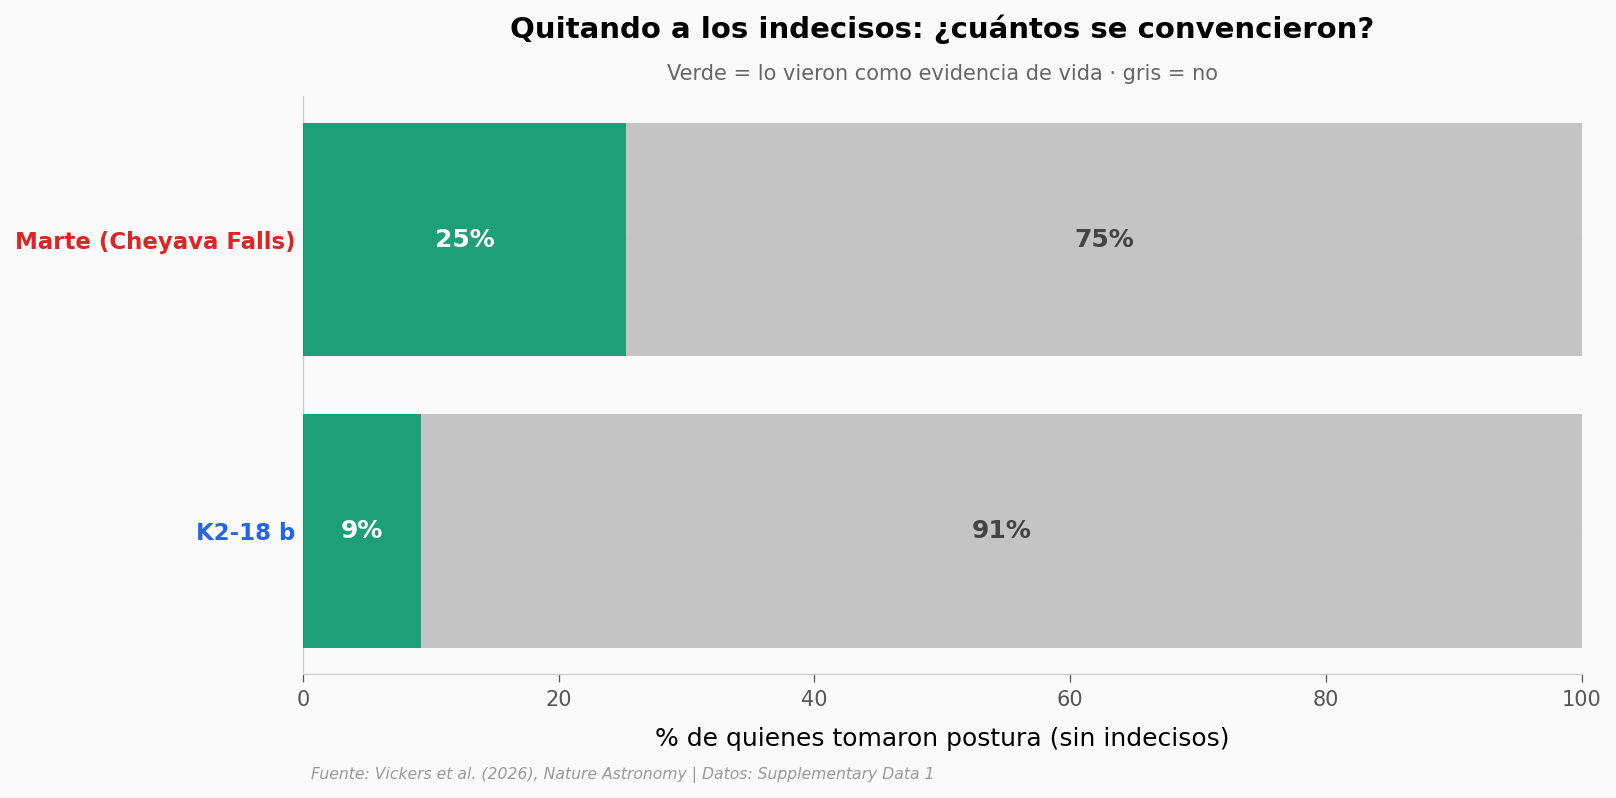

K2-18 b: 9% convencidos, 91% escépticos
Marte  : 25% convencidos, 75% escépticos


In [4]:
# Solo quienes tomaron postura (quitando 'Neutral')
def reparto(df):
    nn = df[df.response_label != 'Neutral']
    a = nn.response_label.isin(['Agree', 'Strongly agree']).mean() * 100
    return a, 100 - a

a_k2, d_k2 = reparto(k2)
a_mars, d_mars = reparto(mars)

fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(2)
nombres = ['K2-18 b', 'Marte (Cheyava Falls)']
convencidos = [a_k2, a_mars]
escepticos = [d_k2, d_mars]

ax.barh(y, convencidos, color='#059669', alpha=0.9, zorder=3, label='Se convencieron')
ax.barh(y, escepticos, left=convencidos, color=COLOR_NEUTRAL, alpha=0.85,
        zorder=3, label='Siguieron escépticos')

for i in range(2):
    ax.text(convencidos[i]/2, y[i], f'{convencidos[i]:.0f}%', ha='center', va='center',
            color='white', fontsize=12, fontweight='bold')
    ax.text(convencidos[i] + escepticos[i]/2, y[i], f'{escepticos[i]:.0f}%',
            ha='center', va='center', color='#444444', fontsize=12, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(nombres, fontsize=11, fontweight='bold')
ax.get_yticklabels()[0].set_color(COLOR_K2)
ax.get_yticklabels()[1].set_color(COLOR_MARS)
ax.set_xlabel('% de quienes tomaron postura (sin indecisos)')
ax.set_xlim(0, 100)
ax.set_title('Quitando a los indecisos: ¿cuántos se convencieron?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Verde = lo vieron como evidencia de vida · gris = no',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escepticismo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"K2-18 b: {a_k2:.0f}% convencidos, {d_k2:.0f}% escépticos")
print(f"Marte  : {a_mars:.0f}% convencidos, {d_mars:.0f}% escépticos")


## ¿Qué tan grande es esa brecha?

Doce puntos porcentuales suena a poco hasta que lo pones en contexto: es un salto del 44% relativo en confianza. Veamos las dos nubes de votos completas, con sus medias marcadas, para medir la distancia de un golpe de vista.

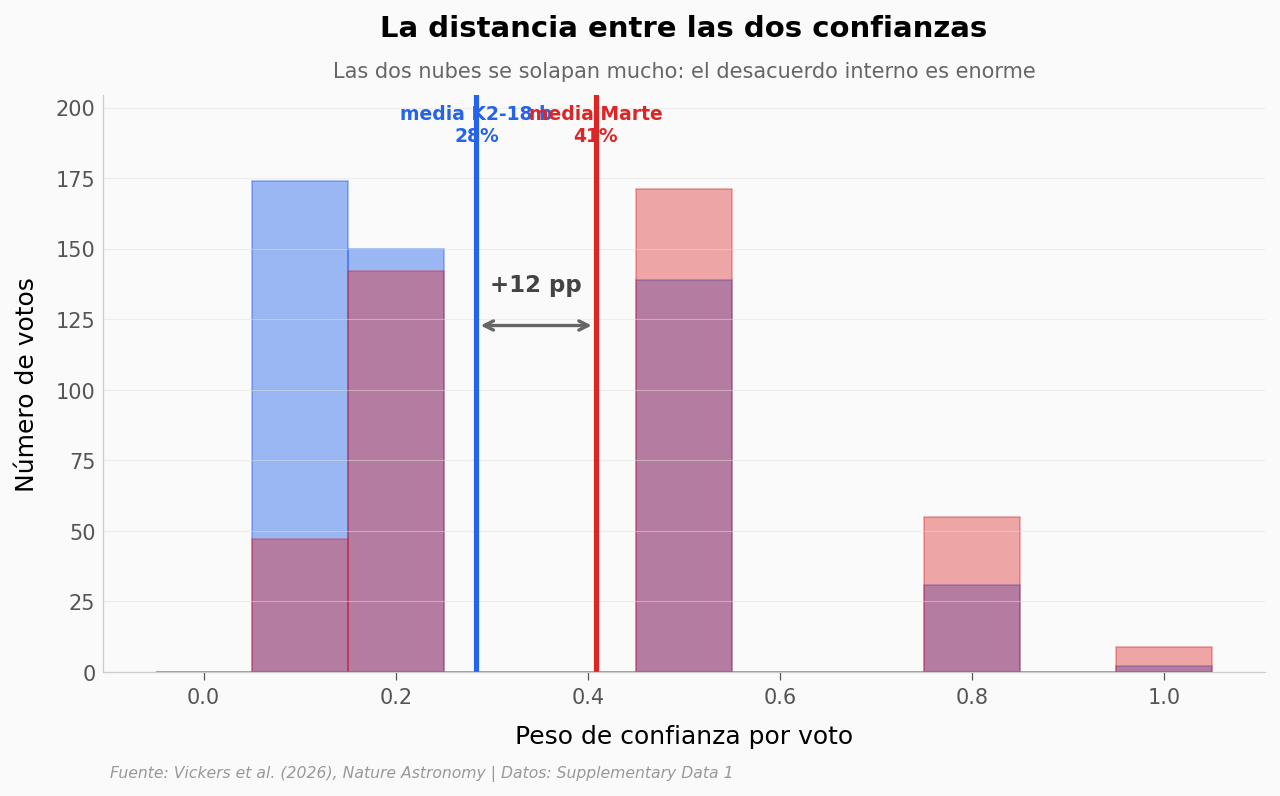

Entropía (dispersión) — K2-18 b: 1.85 bits | Marte: 1.91 bits
Máximo posible (5 opciones equiprobables): 2.32 bits


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(-0.05, 1.05, 12)

ax.hist(k2.credence, bins=bins, color=COLOR_K2, alpha=0.45,
        edgecolor=COLOR_K2, linewidth=0.8, label='K2-18 b')
ax.hist(mars.credence, bins=bins, color=COLOR_MARS, alpha=0.40,
        edgecolor=COLOR_MARS, linewidth=0.8, label='Marte')

m_k2, m_mars = k2.credence.mean(), mars.credence.mean()
y_max = ax.get_ylim()[1]
ax.set_ylim(0, y_max * 1.12)
y_max = ax.get_ylim()[1]

ax.axvline(m_k2, color=COLOR_K2, linewidth=2.5)
ax.axvline(m_mars, color=COLOR_MARS, linewidth=2.5)
ax.annotate('', xy=(m_mars, y_max*0.6), xytext=(m_k2, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.6))
ax.text((m_k2 + m_mars)/2, y_max*0.66, f'+{(m_mars-m_k2)*100:.0f} pp',
        ha='center', fontsize=11, fontweight='bold', color='#444444')
ax.text(m_k2, y_max*0.92, f'media K2-18 b\n{m_k2:.0%}', ha='center',
        fontsize=9, color=COLOR_K2, fontweight='bold')
ax.text(m_mars, y_max*0.92, f'media Marte\n{m_mars:.0%}', ha='center',
        fontsize=9, color=COLOR_MARS, fontweight='bold')

ax.set_xlabel('Peso de confianza por voto')
ax.set_ylabel('Número de votos')
ax.set_title('La distancia entre las dos confianzas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las dos nubes se solapan mucho: el desacuerdo interno es enorme',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distancia_medias.png', dpi=200, bbox_inches='tight')
plt.show()

# Dispersión interna: entropía de Shannon (qué tan repartido está el voto)
def entropia(df):
    p = df.response_label.value_counts(normalize=True).values
    return -np.sum(p * np.log2(p))
print(f"Entropía (dispersión) — K2-18 b: {entropia(k2):.2f} bits | Marte: {entropia(mars):.2f} bits")
print(f"Máximo posible (5 opciones equiprobables): {np.log2(5):.2f} bits")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Marte recibió más confianza media que K2-18 b | ✅ | 41% vs 28%, +12 puntos porcentuales (+44% relativo). Cohen's d = 0,57 (efecto medio) |
| La diferencia no es casualidad estadística | ✅ | Mann-Whitney U = 137.508, p = 3,8·10⁻¹⁷ (variable ordinal, dos grupos independientes) |
| Aun con Marte, la mayoría siguió escéptica | ✅ | Quitando indecisos, 75% no lo vio como evidencia de vida; con K2-18 b fueron 91% |
| Nadie se convenció del todo | ✅ | "Totalmente de acuerdo": 2 votos (K2-18 b) y 9 votos (Marte) de cientos |
| El desacuerdo interno es alto en ambos | ✅ | Entropía 1,85 (K2-18 b) y 1,91 (Marte) bits, de un máximo de 2,32: voto muy repartido |

> **Limitaciones:** Son **dos encuestas independientes** — distintos respondientes, distintas fechas (abril vs septiembre 2025) —, no una comparación pareada persona-por-persona. La encuesta mide **opinión experta**, no la validez física de cada evidencia. Las tasas de respuesta fueron 39% (K2-18 b) y 33% (Marte), así que cabe un sesgo de autoselección: quien responde una encuesta de opinión puede no representar a toda la comunidad. La población es autoidentificada como astrobióloga en la plataforma IASC.

## Ahora tú

1. **¿Y si los indecisos cuentan como "casi no"?** En vez de quitarlos, asígnales medio punto. ¿Cuánto cambia la brecha entre Marte y K2-18 b? *(pista: la columna `credence` ya pone Neutral en 0,5)*
2. **¿Qué tan sensible es la conclusión al peso de los extremos?** Recalcula la media usando solo el código de voto (1 a 5) en vez del peso de confianza. ¿La ventaja de Marte sobrevive? *(pista: `k2.vote.mean()` vs `mars.vote.mean()`)*
3. **¿Votó distinta gente a horas distintas?** La columna `timestamp` tiene fecha y hora. Mira si los primeros votos de cada encuesta fueron más entusiastas que los últimos. *(pista: ordena por `timestamp` y compara la primera mitad con la segunda)*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿la ventaja de Marte sobrevive si usamos el código de voto crudo?
# (vote 1 = totalmente de acuerdo ... 5 = totalmente en desacuerdo; menor = más convencido)

for nombre, df in [('K2-18 b', k2), ('Marte', mars)]:
    voto_medio = df.vote.mean()
    print(f"{nombre:8s}: código de voto medio = {voto_medio:.2f}  "
          f"(más bajo = más convencido)")

dif = k2.vote.mean() - mars.vote.mean()
print(f"\nMarte queda {dif:.2f} puntos de voto más cerca del 'de acuerdo'.")
print("La ventaja sobrevive: cambia la escala, no la dirección.")


K2-18 b : código de voto medio = 3.93  (más bajo = más convencido)
Marte   : código de voto medio = 3.38  (más bajo = más convencido)

Marte queda 0.55 puntos de voto más cerca del 'de acuerdo'.
La ventaja sobrevive: cambia la escala, no la dirección.


---

## Fuentes

**Paper**: [Comparing astrobiologists’ confidence in extraterrestrial life claims for K2-18 b and Cheyava Falls](https://doi.org/10.1038/s41550-026-02876-9)  
*Nature Astronomy, 2026-06-05*

**Supplementary Material**: [Supplementary Data 1 — resultados crudos de las encuestas K2-18 b y Marte (MOESM2, mismo DOI)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41550-026-02876-9/MediaObjects/41550_2026_2876_MOESM2_ESM.xlsx)  
*Nature Astronomy, mismo DOI — resultados crudos de las encuestas*

**Referencias citadas**: [IASC Polls: The Institute for Ascertaining Scientific Consensus Polling Platform](https://zenodo.org/records/8155054)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

**Datos originales:** Vickers et al. (2026), *Nature Astronomy* — Supplementary Data 1 (acceso abierto, mismo DOI). [DOI: 10.1038/s41550-026-02876-9](https://doi.org/10.1038/s41550-026-02876-9)
**Plataforma de encuestas:** IASC Polls (The Institute for Ascertaining Scientific Consensus).
**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY 4.0